# Load and Explore the dataset

In [2]:
import json
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd 
import numpy as np

# Community detection
from networkx.algorithms.community import louvain_communities
from collections import defaultdict

# Node classification
from node2vec import Node2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)



In [3]:
# load the network

G = nx.read_edgelist(
    "congress.edgelist",
    create_using=nx.DiGraph(),
    nodetype=int
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print(f"Nodes range: {min(G.nodes()), max(G.nodes())}")

Nodes: 475
Edges: 13289
Nodes range: (0, 474)


In [4]:
# retrieve self loops and isolated nodes
# remove self loops 

self_loops = list(nx.selfloop_edges(G))
print("Self loops:", len(self_loops))

isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)}")

G.remove_edges_from(self_loops)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Self loops: 0
Isolated nodes: 0
Nodes: 475, Edges: 13289


In [5]:
# map twitter nickname to each node

with open("congress_network_data.json") as f:
    data = json.load(f)

data = data[0]  
username_list = data["usernameList"]
node_to_username = dict(enumerate(username_list))

nx.set_node_attributes(G, node_to_username, "label")

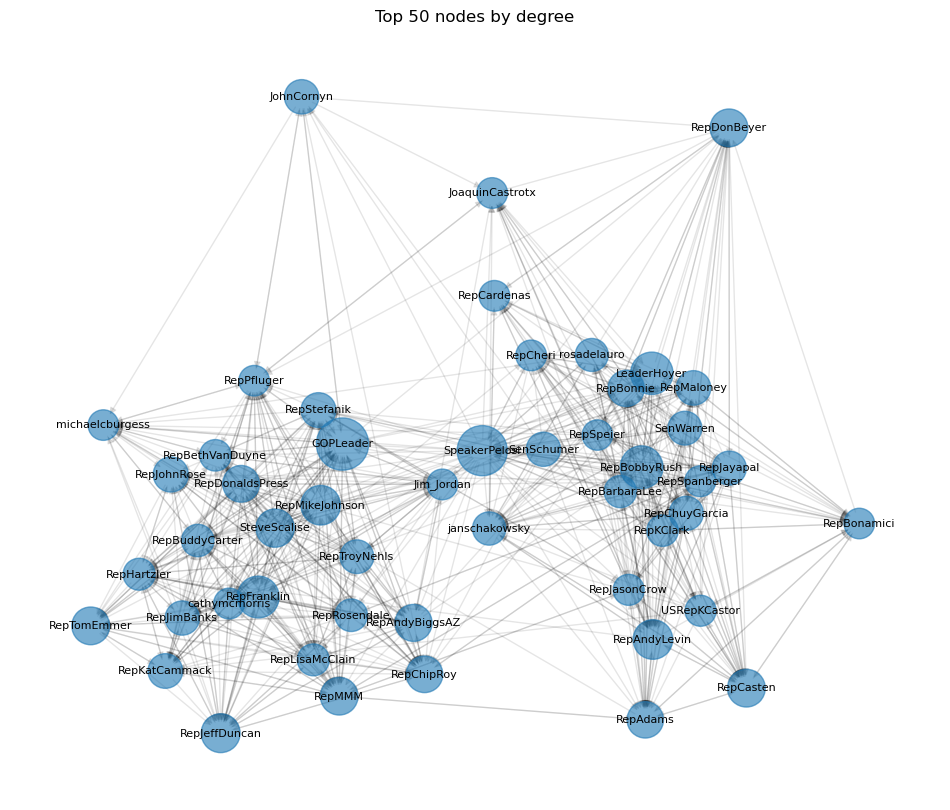

In [7]:
# Visualization: first 50 nodes by total degree

deg_dict = dict(G.degree())
top_nodes = sorted(deg_dict, key=deg_dict.get, reverse=True)[:50]

G_top = G.subgraph(top_nodes).copy()

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_top, seed=42)

nx.draw_networkx_nodes(
    G_top, pos,
    node_size=[G.degree(n) * 5 for n in G_top.nodes()],
    alpha=0.6
)

nx.draw_networkx_edges(
    G_top, pos,
    alpha=0.1,
    arrows=True,
)

nx.draw_networkx_labels(
    G_top, pos,
    labels={n: G.nodes[n].get("label", n) for n in G_top.nodes()},
    font_size=8
)

plt.title("Top 50 nodes by degree")
plt.axis("off")
plt.show()

This figure shows the subnetwork induced by the 50 nodes with the highest degree, with node size depending on their total degree. Several highly connected actors appear at the center of the structure, indicating that interactions are concentrated around a relatively small group of prominent accounts. The largest nodes, including SpeakerPelosi, GOPLeader, LeaderHoyer, and RepBobbyRush, function as hubs.

The visualization highlights a dense core of highly connected actors surrounded by more peripheral nodes, such as JohnCornyn and RepDonBeyer. This core–periphery structure suggests that a large share of interactions occurs among a relatively small set of central accounts.

Finally, some nodes appear positioned between clusters, suggesting that they may play a bridging role between different parts of the network (e.g., janschakowsky, JimJordan, RepChipRoy).

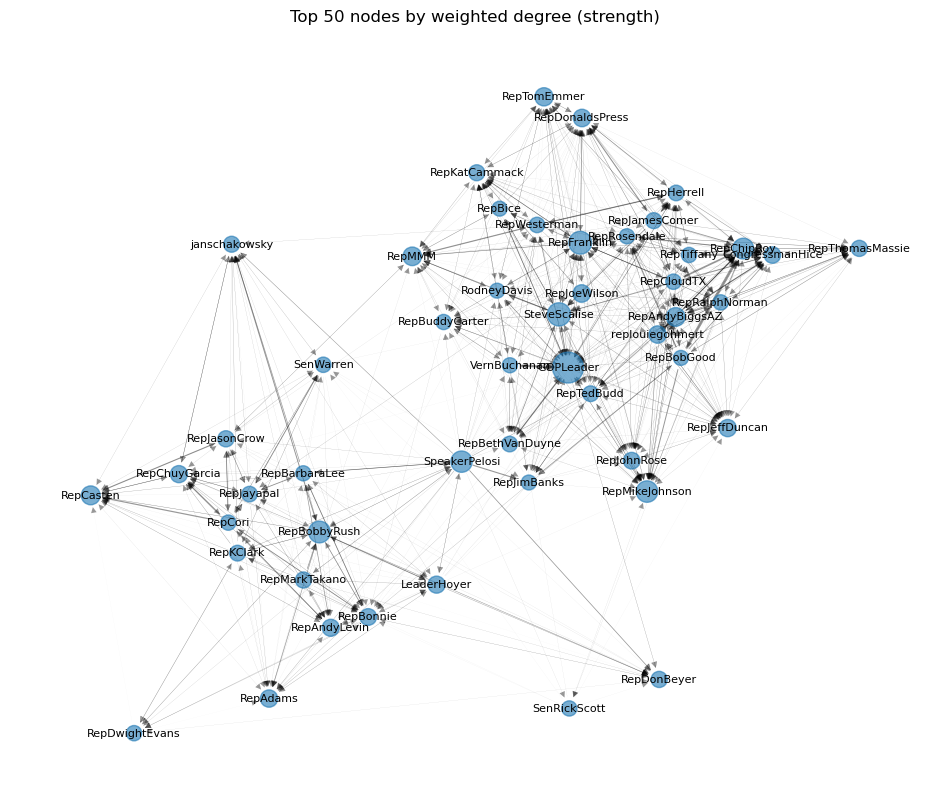

In [8]:
# plot 50 nodes by weighted degree
strength_dict = dict(G.degree(weight="weight"))

top_nodes = sorted(strength_dict, key=strength_dict.get, reverse=True)[:50]
G_top = G.subgraph(top_nodes).copy()

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_top, seed=42)

nx.draw_networkx_nodes(
    G_top, pos,
    node_size=[strength_dict[n] * 200 for n in G_top.nodes()],
    alpha=0.6
)

nx.draw_networkx_edges(
    G_top, pos,
    width=[G_top[u][v].get("weight", 1) * 20 for u, v in G_top.edges()],
    alpha=0.4,
    arrows=True
)

nx.draw_networkx_labels(
    G_top, pos,
    labels={n: G.nodes[n].get("label", n) for n in G_top.nodes()},
    font_size=8
)

plt.title("Top 50 nodes by weighted degree (strength)")
plt.axis("off")
plt.show()

This visualization shows the 50 nodes with the highest weighted degree (strength), where node size is proportional to the sum of the weights of their connections. The overall structure is consistent with the previous degree-based visualization: a dense core of highly connected actors emerges at the center of the network. Prominent nodes such as SpeakerPelosi, SteveScalise, and GOPLeader remain among the most central actors, indicating that they not only interact with many accounts but also concentrate a large share of the interaction volume. This confirms that a relatively small group of accounts dominates both the number and the intensity of interactions in the network.
As seen before, some nodes also appear positioned between clusters (e.g., janschakowsky, JimJordan, RepChipRoy), suggesting that they may play a bridging role between different parts of the network.

Nodes: 83
Edges: 50


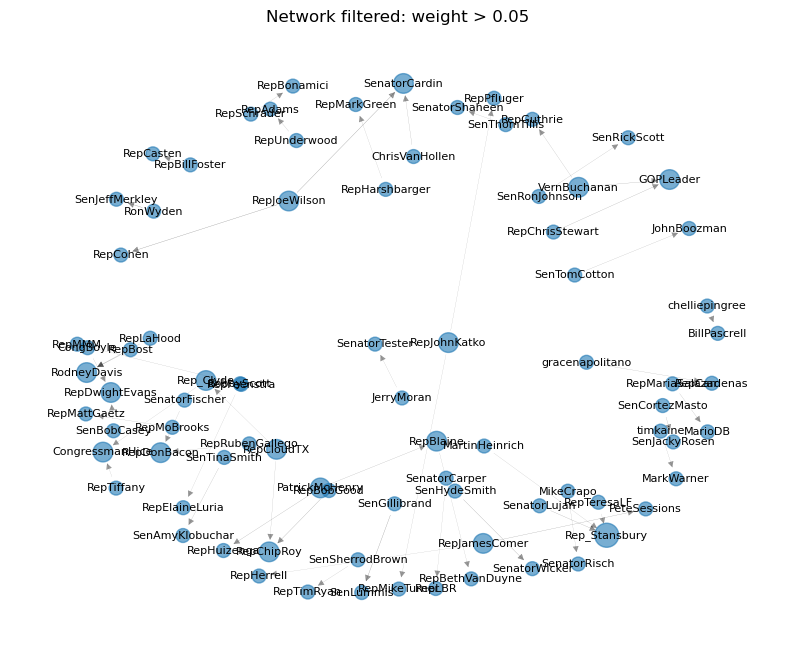

In [9]:
# plot of edges with weight > 0.05
edges_keep = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 0) > 0.05]

# crea un nuovo grafo filtrato
G_filt = nx.DiGraph()
G_filt.add_nodes_from(G.nodes(data=True))
G_filt.add_edges_from((u, v, G[u][v]) for u, v in edges_keep)

# rimuovi nodi isolati
G_filt.remove_nodes_from(list(nx.isolates(G_filt)))

print("Nodes:", G_filt.number_of_nodes())
print("Edges:", G_filt.number_of_edges())

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G_filt, seed=42)

nx.draw_networkx_nodes(
    G_filt, pos,
    node_size=[G_filt.degree(n)*100 for n in G_filt.nodes()],
    alpha=0.6
)

nx.draw_networkx_edges(
    G_filt, pos,
    width=[G_filt[u][v]["weight"]*2 for u,v in G_filt.edges()],
    alpha=0.4,
    arrows=True
)

nx.draw_networkx_labels(
    G_filt, pos,
    labels={n: G_filt.nodes[n].get("label", n) for n in G_filt.nodes()},
    font_size=8
)

plt.title("Network filtered: weight > 0.05")
plt.axis("off")
plt.show()


This visualization shows the network after filtering edges with weight greater than 0.05, retaining only relatively strong interactions. Compared with the previous graphs, the network becomes much sparser and breaks into smaller clusters of actors who interact more frequently with each other. This filtering highlights the strongest relationships in the network and reduces the influence of weaker or sporadic interactions, making the underlying interaction structure more visible.

In force-directed layouts, nodes with connections to multiple parts of the network tend to be positioned near the center of the visualization. Accordingly, actors located in the central region of the graph (e.g., SenatorTester) likely interact with several different clusters, potentially facilitating interactions between otherwise more separated groups. Conversely, nodes located at the periphery tend to interact mainly within a smaller subset of actors.


## Descriptive Metrics

#### Basic structural properties of the network

In [ ]:
density = nx.density(G)
global_reciprocity = nx.reciprocity(G)

print("Is directed:", nx.is_directed(G))
print(f"Density: {density:.4f}")
print("Is strongly connected:", nx.is_strongly_connected(G))
print(f"Global reciprocity: {global_reciprocity:.4f}")

Is directed: True
Density: 0.0590
Is strongly connected: False
Global reciprocity: 0.4616


The network is directed, meaning that interactions have a clear direction from one node to another. 

The density is relatively low (0.059), indicating that only a small fraction of all possible connections between nodes is present. The network is not strongly connected, which means that it is not possible to reach every node from every other node following the direction of the edges. 

Finally, the global reciprocity is 0.4616, suggesting that a substantial share of interactions are mutual, with pairs of nodes interacting with each other in both directions.

#### Connected components

In [9]:
# Weakly and strongly connected components
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
wcc_sizes = []
for c in wcc:
    wcc_sizes.append(len(c))
wcc_sizes = sorted(wcc_sizes,reverse=True)

scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)

print(f"Number of weakly connected components: {len(wcc)}")
print(f"    Sizes of the 5 largest WCCs: {wcc_sizes[:5]}")

print(f"Number of strongly connected components: {len(scc)}")
print(f"    Sizes of the 5 largest SCCs: {scc_sizes[:5]}")

Number of weakly connected components: 1
    Sizes of the 5 largest WCCs: [475]
Number of strongly connected components: 7
    Sizes of the 5 largest SCCs: [469, 1, 1, 1, 1]


The network forms a single weakly connected component, indicating that all nodes belong to the same overall structure when ignoring edge direction. However, as mentioned before, it is not strongly connected: there are 7 strongly connected components, with one large component of 469 nodes and several isolated nodes.

#### In-degree and Out-degree Distribution

In [12]:
# Compute in-degree and out-degree
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Convert to pandas DataFrame for convenience
deg_df = pd.DataFrame({
    "node": list(G.nodes()),
    "nickname": [G.nodes[n].get("label", n) for n in G.nodes()],    
    "in_degree": [in_degrees[n] for n in G.nodes()],
    "out_degree": [out_degrees[n] for n in G.nodes()]
})
deg_df["total_degree"] = deg_df["in_degree"] + deg_df["out_degree"]

deg_df.sort_values("total_degree", ascending=False).head()

,node,nickname,in_degree,out_degree,total_degree
270,322,GOPLeader,127,157,284
121,367,SpeakerPelosi,51,210,261
88,393,RepBobbyRush,79,111,190
51,254,LeaderHoyer,108,79,187
313,208,RepFranklin,121,61,182


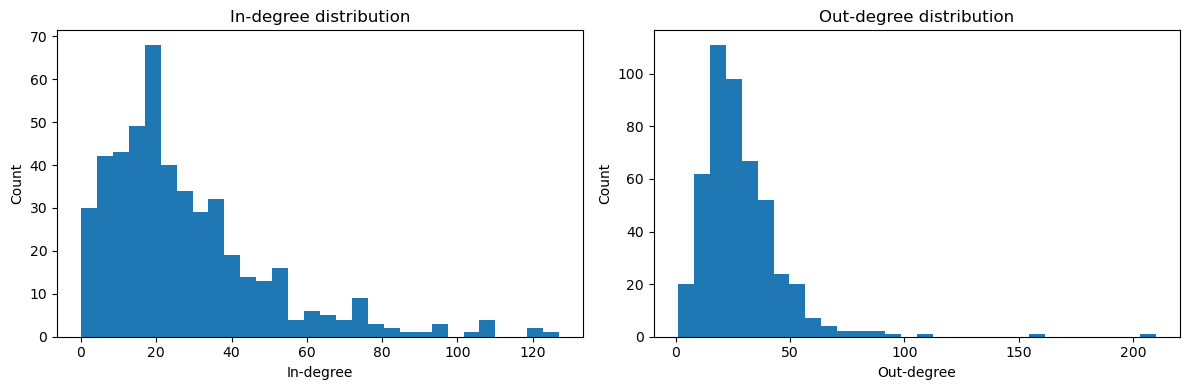

In [13]:
# Plot in-degree and out-degree distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(deg_df["in_degree"], bins=30)
axes[0].set_title("In-degree distribution")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Count")

axes[1].hist(deg_df["out_degree"], bins=30)
axes[1].set_title("Out-degree distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The distributions of in-degree and out-degree describe how interactions are distributed among nodes in the directed network. Both distributions are right-skewed: most nodes have relatively few connections, while a small number of actors have very high degree values. This indicates the presence of highly connected nodes that concentrate a large share of the interactions in the network.

The table of top nodes confirms the presence of highly connected actors that concentrate a large share of the interactions in the network. In particular, accounts such as GOPLeader, SpeakerPelosi, RepBobbyRush, and LeaderHoyer once again emerge among the nodes with the highest total degree. These actors combine high levels of received interactions (in-degree) and initiated interactions (out-degree), highlighting their central role in the network’s interaction structure.

#### Clustering coefficient

In [15]:
# Convert to undirected for clustering measures
G_und = G.to_undirected()

# Compute global metrics
global_clustering = nx.transitivity(G_und)
avg_local_clustering = nx.average_clustering(G_und)

print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")
print(f"Average local clustering: {avg_local_clustering:.4f}")

Global clustering coefficient (transitivity): 0.2695
Average local clustering: 0.3014


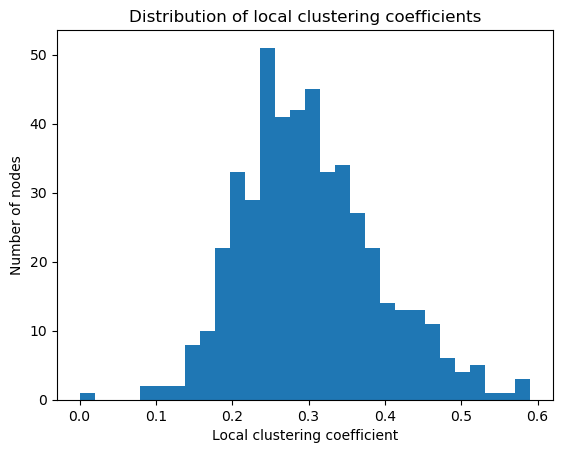

In [16]:
# Distribution of local clustering coefficients

clustering_dict = nx.clustering(G_und)
clustering_values = list(clustering_dict.values())

plt.hist(clustering_values, bins=30)
plt.xlabel("Local clustering coefficient")
plt.ylabel("Number of nodes")
plt.title("Distribution of local clustering coefficients")
plt.show()

To compute clustering measures, the network was converted to an undirected graph. The global clustering coefficient (transitivity) is 0.2695, indicating a moderate tendency for nodes to form closed triangles. The average local clustering coefficient (0.3014) suggests that, on average, the neighbors of a node are relatively likely to be connected with each other.

The distribution of local clustering coefficients shows that most nodes have values between approximately 0.2 and 0.4, indicating a moderate level of local cohesiveness in the network. This suggests that interactions often occur within small groups of interconnected actors rather than being completely random.

#### Bridges

In [17]:
# Compute bridges on undirected graph
bridges = list(nx.bridges(G_und))
print(f"Number of bridges in the undirected graph: {len(bridges)} ({round(len(bridges)/G_und.size()*100,2)}% of edges)")

# Compute bridges
local_bridges = list(nx.local_bridges(G_und, with_span = False))
print(f"Number of local bridges in the undirected graph: {len(local_bridges)} - ({round(len(local_bridges)/G_und.size()*100,2)}% of edges)")

# Table
local_bridges_df = pd.DataFrame(local_bridges, columns=["node_u", "node_v"])
local_bridges_df["label_u"] = local_bridges_df["node_u"].apply(lambda n: G.nodes[n].get("label", n))
local_bridges_df["label_v"] = local_bridges_df["node_v"].apply(lambda n: G.nodes[n].get("label", n))
local_bridges_df = local_bridges_df[["node_u", "label_u", "node_v", "label_v"]]

local_bridges_df.head(10)

Number of bridges in the undirected graph: 0 (0.0% of edges)
Number of local bridges in the undirected graph: 94 - (0.92% of edges)


,node_u,label_u,node_v,label_v
0,18,SenCortezMasto,217,RepSylviaGarcia
1,58,ChrisMurphyCT,381,RepKathleenRice
2,76,SenTinaSmith,336,RepCarolMiller
3,341,RepGwenMoore,419,RepSmucker
4,17,JohnCornyn,152,RepLizCheney
5,79,SenatorTester,396,RepMariaSalazar
6,79,SenatorTester,407,AustinScottGA08
7,213,RepGaramendi,240,RepJoshHarder
8,250,jahimes,69,marcorubio
9,250,jahimes,406,RepDavid


#### Comment
The undirected network contains no bridges, indicating that no single edge is structurally critical for maintaining global connectivity. This suggests a highly redundant structure with multiple alternative paths between nodes. However, 94 local bridges (0.92% of edges) are present, representing ties that connect otherwise unshared neighborhoods and potentially linking different communities.

The table above shows some examples of these ties. Among them, JohnCornyn was already identified among the nodes with the highest total degree, while SenatorTester appeared in a relatively central position in the filtered network visualization (weight > 0.05). Their presence among the local bridges suggests that some highly connected or structurally central actors may also participate in ties that link otherwise weakly connected parts of the network.

Interestingly, several of the local bridges involve nodes whose labels suggest membership in different chambers of Congress. In particular, a number of edges connect accounts labeled with the prefix Sen (senators) to accounts labeled with Rep (representatives). This pattern may indicate interactions that link actors from the Senate and the House of Representatives, potentially contributing to connectivity across different institutional groups.

#### Centrality Measures

In [18]:
# Degree centrality (undirected)
deg_cent = nx.degree_centrality(G_und)

# Betweenness centrality (undirected)
bet_cent = nx.betweenness_centrality(G_und, normalized=True)

# Closeness centrality (undirected)
clo_cent = nx.closeness_centrality(G_und)

# PageRank (directed)
pr = nx.pagerank(G, alpha=0.85)

# In-degree and out-degree
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Node labels (twitter usernames)
labels = nx.get_node_attributes(G, "label")

# Build centrality dataframe
centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "label": [labels.get(n, n) for n in G.nodes()],
    "degree_centrality": [deg_cent[n] for n in G.nodes()],
    "betweenness_centrality": [bet_cent[n] for n in G.nodes()],
    "closeness_centrality": [clo_cent[n] for n in G.nodes()],
    "pagerank": [pr[n] for n in G.nodes()],
    "in_degree": [in_deg[n] for n in G.nodes()],
    "out_degree": [out_deg[n] for n in G.nodes()]
})

centrality_df.sort_values("pagerank", ascending=False).head(10)

,node,label,degree_centrality,betweenness_centrality,closeness_centrality,pagerank,in_degree,out_degree
270,322,GOPLeader,0.381857,0.037183,0.617188,0.016696,127,157
81,147,RepCasten,0.219409,0.007614,0.549247,0.012845,97,51
105,389,RepChipRoy,0.194093,0.005526,0.547977,0.011028,84,55
298,269,RepMikeJohnson,0.236287,0.007737,0.555035,0.010660,106,57
84,215,RepChuyGarcia,0.177215,0.004055,0.544202,0.010580,76,45
313,208,RepFranklin,0.282700,0.015459,0.570397,0.008885,121,61
126,92,RepAdams,0.221519,0.013185,0.558304,0.008246,94,44
101,246,CongressmanHice,0.132911,0.002414,0.522602,0.008157,59,29
207,303,RepAndyLevin,0.217300,0.009322,0.546713,0.008033,97,66
287,113,RepAndyBiggsAZ,0.204641,0.007742,0.551163,0.008026,77,65


The table reports several centrality measures for the nodes in the network, including degree centrality, betweenness centrality, closeness centrality, and PageRank. Nodes are ranked according to their PageRank score, which reflects the structural importance of actors in the directed network by taking into account both the number and the importance of incoming connections.

The results highlight several prominent actors, including GOPLeader, RepCasten, and RepChipRoy (all right-wing politicians), which appear among the nodes with the highest PageRank values. In particular, GOPLeader shows the highest PageRank and also exhibits high values in degree centrality and betweenness centrality, suggesting a structurally central role in the network. The presence of several Republican accounts may indicate that some actors from this political group play a prominent role in the interaction structure of the network. This could reflect differences in communication patterns or interaction dynamics within the dataset.

In [ ]:
# Key nodes
def show_top(df, col, k=10):
    print(f"\nTop {k} nodes by {col}:")
    display(
        df.sort_values(col, ascending=False)
          .reset_index(drop=True)
          .head(k)[["node", "label", col, "in_degree", "out_degree"]]
    )

show_top(centrality_df, "degree_centrality")
show_top(centrality_df, "betweenness_centrality")
show_top(centrality_df, "closeness_centrality")
show_top(centrality_df, "pagerank")


Top 10 nodes by degree_centrality:


,node,label,degree_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.451477,51,210
1,322,GOPLeader,0.381857,127,157
2,254,LeaderHoyer,0.299578,108,79
3,208,RepFranklin,0.282700,121,61
4,393,RepBobbyRush,0.272152,79,111
5,190,RepJeffDuncan,0.267932,120,37
6,111,RepDonBeyer,0.253165,109,39
7,192,RepTomEmmer,0.238397,105,43
8,269,RepMikeJohnson,0.236287,106,57
9,385,RepJohnRose,0.234177,108,20



Top 10 nodes by betweenness_centrality:


,node,label,betweenness_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.068626,51,210
1,322,GOPLeader,0.037183,127,157
2,254,LeaderHoyer,0.022623,108,79
3,208,RepFranklin,0.015459,121,61
4,17,JohnCornyn,0.014895,72,51
5,71,SenSchumer,0.013771,25,97
6,393,RepBobbyRush,0.013559,79,111
7,461,RepBonnie,0.013285,75,62
8,92,RepAdams,0.013185,94,44
9,190,RepJeffDuncan,0.013048,120,37



Top 10 nodes by closeness_centrality:


,node,label,closeness_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.645777,51,210
1,322,GOPLeader,0.617188,127,157
2,254,LeaderHoyer,0.585185,108,79
3,111,RepDonBeyer,0.571084,109,39
4,393,RepBobbyRush,0.570397,79,111
5,208,RepFranklin,0.570397,121,61
6,461,RepBonnie,0.561611,75,62
7,92,RepAdams,0.558304,94,44
8,190,RepJeffDuncan,0.557647,120,37
9,71,SenSchumer,0.556338,25,97



Top 10 nodes by pagerank:


,node,label,pagerank,in_degree,out_degree
0,322,GOPLeader,0.016696,127,157
1,147,RepCasten,0.012845,97,51
2,389,RepChipRoy,0.011028,84,55
3,269,RepMikeJohnson,0.010660,106,57
4,215,RepChuyGarcia,0.010580,76,45
5,208,RepFranklin,0.008885,121,61
6,92,RepAdams,0.008246,94,44
7,246,CongressmanHice,0.008157,59,29
8,303,RepAndyLevin,0.008033,97,66
9,113,RepAndyBiggsAZ,0.008026,77,65


### Comment
An interesting point emerges when comparing the various centrality measures. SpeakerPelosi ranks highest in degree, betweenness, and closeness centrality, indicating a very central structural position in the network. However, GOPLeader obtains the highest PageRank score. Since PageRank takes the direction of interactions into account, this result suggests that GOPLeader receives attention from other influential actors in the network. 

A closer look at the in-degree and out-degree values helps explain this difference. SpeakerPelosi shows a very high out-degree, indicating a highly active account that interacts with many others in the network. In contrast, GOPLeader receives a larger number of incoming interactions, which contributes to its higher PageRank score. This pattern suggests that while SpeakerPelosi plays a very active role in the interaction structure, GOPLeader occupies a more prominent position as a recipient of interactions from other actors.This distinction highlights how different actors may occupy different roles in the network, such as highly active participants versus highly referenced or influential nodes.

#### Community Detection

In [ ]:
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

print("Running Louvain community detection...")
louvain_comms = louvain_communities(G_und, seed=42)

print(f"Detected {len(louvain_comms)} communities.")

Running Louvain community detection...
Detected 4 communities.


In [ ]:
# Node -> community mapping
community_map = {}

for i, comm in enumerate(louvain_comms):
    for node in comm:
        community_map[node] = i

centrality_df["community"] = centrality_df["node"].map(community_map)

nx.set_node_attributes(G, community_map, "community")
nx.set_node_attributes(G_und, community_map, "community")

# Save graph for GDV computation in Colab
nx.write_edgelist(G_und, "G_und.edgelist")

In [22]:
# Dataset for ML tasks (node classification)
ml_df = pd.DataFrame({
    "node": list(community_map.keys()),
    "community": list(community_map.values())
})

print(ml_df["community"].value_counts().sort_index())
print(sorted(ml_df["community"].unique()))

ml_df.head()

community
0    190
1     92
2     15
3    178
Name: count, dtype: int64
[0, 1, 2, 3]


,node,community
0,35,0
1,53,0
2,70,0
3,92,0
4,94,0


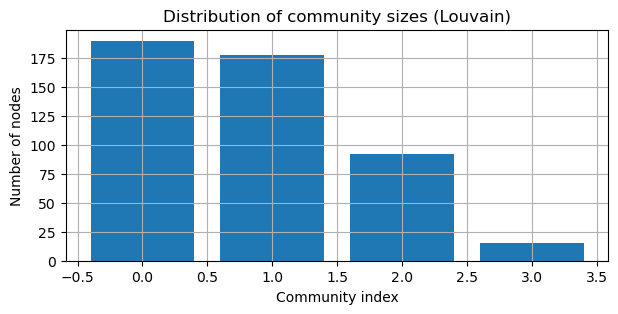

Number of communities: 4
Smallest community: 15 nodes
Largest community: 190 nodes


In [23]:
# Compute community sizes
community_sizes = sorted([len(c) for c in louvain_comms], reverse = True)

# Plot histogram
plt.figure(figsize=(7,3))
plt.bar(range(len(community_sizes)),community_sizes)
plt.xlabel("Community index")
plt.ylabel("Number of nodes")
plt.title("Distribution of community sizes (Louvain)")
plt.grid(True)
plt.show()

# Print summary stats
print(f"Number of communities: {len(community_sizes)}")
print(f"Smallest community: {min(community_sizes)} nodes")
print(f"Largest community: {max(community_sizes)} nodes")

In [24]:
# Avg centrality measures by community
centrality_df.groupby("community").agg(
    n_nodes=("node", "count"),
    avg_pagerank=("pagerank", "mean"),
    avg_degree=("degree_centrality", "mean"),
    max_pagerank=("pagerank", "max")
).sort_values("avg_pagerank", ascending=False)

,n_nodes,avg_pagerank,avg_degree,max_pagerank
community,,,,
3,178,0.002382,0.093609,0.016696
0,190,0.002204,0.095803,0.012845
2,15,0.001870,0.071027,0.005226
1,92,0.001403,0.078265,0.005677


In [25]:
# Assortativity
nx.attribute_assortativity_coefficient(G_und, "community")

0.6089383686206323

##### Comment
The degree assortativity coefficient is 0.61, indicating a strongly assortative network. This means that nodes tend to connect with other nodes having a similar degree, suggesting that highly connected nodes preferentially interact with other highly connected nodes, while low-degree nodes tend to link to similarly less connected nodes.

[[0.33036588 0.04294659 0.00997848 0.03873997]
 [0.04294659 0.09577382 0.00523381 0.02298963]
 [0.00997848 0.00523381 0.00342399 0.00606535]
 [0.03873997 0.02298963 0.00606535 0.31852866]]


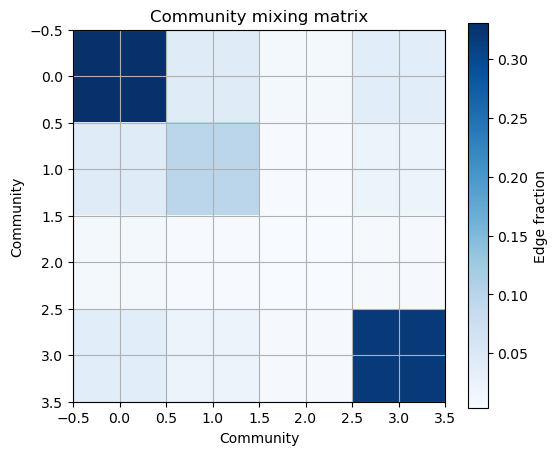

In [26]:
# links among communities
mix_matrix = nx.attribute_mixing_matrix(G_und, "community")

print(mix_matrix)

plt.figure(figsize=(6,5))
plt.imshow(mix_matrix, cmap="Blues")
plt.colorbar(label="Edge fraction")
plt.xlabel("Community")
plt.ylabel("Community")
plt.title("Community mixing matrix")
plt.show()

In [27]:
# Modularity score
from networkx.algorithms.community.quality import modularity

mod_score = modularity(G_und, louvain_comms)
mod_score_w = modularity(G_und, louvain_comms, weight="weight")

print(f"Unweighted modularity score: {mod_score:.4f}")
print(f"Weighted modularity score: {mod_score_w:.4f}")

Unweighted modularity score: 0.4385
Weighted modularity score: 0.4385


##### Comment
The modularity score is 0.4385, both in the weighted and unweighted cases. This relatively high value indicates a clear community structure in the network, with nodes forming well-defined modules that are more densely connected internally than with the rest of the network. The identical values suggest that edge weights do not substantially alter the detected community structure.

In [28]:
rows = []

for u, v in G.edges():
    rows.append({
        "source_node": u,
        "source_community": G.nodes[u].get("community"),
        "target_node": v,
        "target_community": G.nodes[v].get("community")
    })

edges_comm_df = pd.DataFrame(rows)

comm_flow_matrix = pd.crosstab(
    edges_comm_df["source_community"],
    edges_comm_df["target_community"]
).sort_index().sort_index(axis=1)

comm_flow_matrix

target_community,0,1,2,3
source_community,,,,
0,4388,403,146,489
1,711,1338,74,366
2,114,60,51,87
3,439,201,69,4353


In [29]:
total_edges = comm_flow_matrix.values.sum()
intra_edges = comm_flow_matrix.values.diagonal().sum()

print(f"Intra-community edges: {intra_edges/total_edges:.2%}")
print(f"Inter-community edges: {(total_edges-intra_edges)/total_edges:.2%}")

Intra-community edges: 76.23%
Inter-community edges: 23.77%


#### Comment
The directed community-to-community edge matrix reveals a clear modular structure in the network. Most edges occur within the same community, as shown by the large values along the diagonal, which is consistent with the overall distribution of edges: approximately 76.23% are intra-community, while 23.77% connect different communities. This indicates that nodes tend to interact primarily within their own module, confirming the presence of strong internal cohesion. At the same time, inter-community connections are not evenly distributed. In particular, communities 0 and 3 exchange the largest number of edges, suggesting that they form the main interface between otherwise densely connected parts of the network.

In [30]:
# Edge betweenness
edge_bet = nx.edge_betweenness_centrality(G_und, weight=None)

rows = []

for u, v, span in nx.local_bridges(G_und, with_span=True):
    
    rows.append({
        "source_node": u,
        "source_label": G_und.nodes[u].get("label", str(u)),
        "source_community": G_und.nodes[u].get("community"),
        "target_node": v,
        "target_label": G_und.nodes[v].get("label", str(v)),
        "target_community": G_und.nodes[v].get("community"),
        "same_community": G_und.nodes[u].get("community") == G_und.nodes[v].get("community"),
        "span": span,
        "edge_betweenness": edge_bet.get((u, v), edge_bet.get((v, u)))
    })

local_bridges_df = pd.DataFrame(rows)

local_bridges_df = local_bridges_df.sort_values(
    by="edge_betweenness",
    ascending=False
).reset_index(drop=True)

local_bridges_df.head(15)

,source_node,source_label,source_community,target_node,target_label,target_community,same_community,span,edge_betweenness
0,408,BobbyScott,0,395,Kilili_Sablan,0,True,3,0.002236
1,264,RepJeffries,0,395,Kilili_Sablan,0,True,3,0.001977
2,350,RepTroyNehls,3,146,RepEdCase,0,False,3,0.001176
3,229,RepJoshG,2,434,RepTomSuozzi,2,True,3,0.000928
4,175,RodneyDavis,3,366,RepDonaldPayne,0,False,3,0.000923
5,452,RepBethVanDuyne,3,463,PeterWelch,1,False,3,0.000895
6,440,RepTiffany,3,434,RepTomSuozzi,2,False,3,0.000858
7,334,RepKweisiMfume,2,426,RepPeteStauber,3,False,3,0.000830
8,5,RoyBlunt,1,242,RepHartzler,3,False,3,0.000827
9,280,RepDanKildee,0,323,RepMcCaul,3,False,3,0.000812


In [31]:
# number and percentage of local bridges linking different communities
print(local_bridges_df["same_community"].value_counts())
print(f"Percentage of local bridges connecting different communities: {1 - local_bridges_df['same_community'].mean():.4f}")

same_community
False    78
True     16
Name: count, dtype: int64
Percentage of local bridges connecting different communities: 0.8298


In [32]:
# count matrix
comm_matrix = pd.crosstab(
    local_bridges_df["source_community"],
    local_bridges_df["target_community"]
)

comm_matrix = comm_matrix.add(comm_matrix.T, fill_value=0)

comm_matrix = comm_matrix.sort_index().sort_index(axis=1)

comm_matrix.index.name = None
comm_matrix.columns.name = None

comm_matrix

,0,1,2,3
0,20,13,3,46
1,13,6,0,13
2,3,0,2,3
3,46,13,3,4


#### Comment
Although no global bridges are present in the network, 94 local bridges were identified. The vast majority of these edges connect nodes belonging to different Louvain communities, indicating that they function as structural links between otherwise densely connected modules. While the edge betweenness values remain relatively small, this is expected in large and dense networks where shortest paths are distributed across many alternative routes. The community × community matrix further clarifies the distribution of these bridges: most cross-community links occur between communities 0 and 3, indicating that these two modules form the main structural interface of the network, consistent with the earlier analysis of intra- and inter-community edges. Community 1 also maintains several connections with both communities 0 and 3, whereas community 2 appears more weakly connected to the rest of the network.

# Visualization

### Visualization in Gephi with filter for gedree > 40
The network exhibits a dense core structure, where highly connected nodes form a tightly interconnected subgraph. Even when restricting the visualization to nodes with degree greater than 40, the resulting network remains extremely dense, suggesting that the central actors are strongly connected both within and across communities. This pattern is consistent with the moderate modularity value (0.44), indicating the presence of communities that are nonetheless highly interconnected.

### Visualization for community

In [ ]:
# community per nodo
communities = nx.get_node_attributes(G_und, "community")

# conteggio archi tra community
community_edges = defaultdict(int)

for u, v in G_und.edges():
    cu = communities[u]
    cv = communities[v]

    if cu != cv:
        community_edges[(cu, cv)] += 1

# costruzione grafo delle community
G_comm = nx.Graph()

for (c1, c2), w in community_edges.items():
    if G_comm.has_edge(c1, c2):
        G_comm[c1][c2]["weight"] += w
    else:
        G_comm.add_edge(c1, c2, weight=w)

# aggiungi dimensione community
from collections import Counter
sizes = Counter(communities.values())

for c in G_comm.nodes():
    G_comm.nodes[c]["size"] = sizes[c]

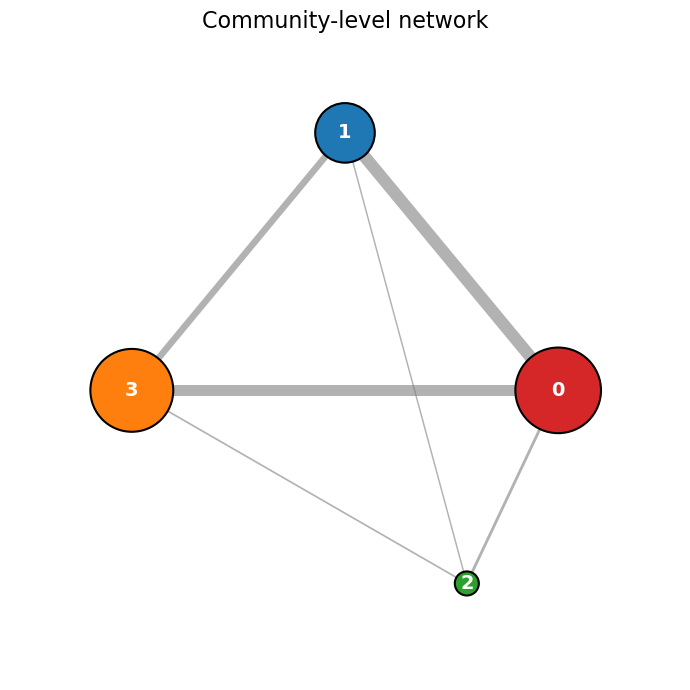

In [34]:
plt.figure(figsize=(7,7))

pos = {
    0: (0.9, 0.45),
    1: (0.55, 0.85),
    2: (0.75, 0.15),
    3: (0.2, 0.45)
}

node_sizes = [G_comm.nodes[n]['size'] * 20 for n in G_comm.nodes()]
edge_widths = [G_comm[u][v]['weight'] / 100 for u, v in G_comm.edges()]
colors = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

nx.draw_networkx_edges(
    G_comm,
    pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.6
)

nx.draw_networkx_nodes(
    G_comm,
    pos,
    node_size=node_sizes,
    node_color=colors[:len(G_comm.nodes())],
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_labels(
    G_comm,
    pos,
    font_size=14,
    font_weight="bold",
    font_color="white"
)

plt.title("Community-level network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.xlim(0,1.1)
plt.ylim(0,1)
plt.show()

# 7. Machine Learning Task: Node Classification

In this section we evaluate whether the structural position of nodes in the network can be used to predict their community membership.
The task is formulated as a node classification problem, where the label of each node corresponds to the community detected in the previous section.

To represent nodes numerically, we compare two different approaches to node representation learning:
* Node2Vec embeddings, which learn vector representations through biased random walks and a skip-gram model.
* Graphlet Degree Vectors (GDV), which explicitly describe the local structural role of each node by counting its participation in small induced subgraphs.

These two methods capture complementary aspects of the network structure. Node2Vec learns latent embeddings based on network proximity, while GDV provides an explicit structural description of local topology. Comparing them allows us to assess whether community membership is better explained by embedding similarity or by local structural patterns.

To ensure a fair comparison, the same stratified train–test split is used across all experiments. The classification model (logistic regression) and evaluation metrics remain the same; only the feature extraction method changes.

### Node2Vec embeddings
Node embeddings are learned using the Node2Vec algorithm, which generates random walks from each node and trains a skip-gram model to predict nodes appearing in the same walk context. This process places nodes with similar network neighborhoods close to each other in the embedding space.

Different Node2Vec configurations are evaluated by varying the parameter q, which controls the exploration strategy of the random walks. Larger values of 𝑞 bias the walk toward a BFS-like behavior, emphasizing local neighborhoods. Since community membership is largely determined by local connectivity patterns, this strategy is expected to improve node classification performance.

### Graphlet Degree Vectors (GDV)

To complement Node2Vec embeddings, we also consider a structural node representation based on Graphlet Degree Vectors (GDV). GDV summarizes the local topological role of each node by counting how many times it participates in different graphlet orbits (small induced subgraphs).

While Node2Vec captures node similarity through random-walk contexts, GDV explicitly characterizes local structural patterns in the network. This makes GDV a useful baseline for evaluating whether community membership is primarily explained by local topology rather than by latent embedding proximity.

In addition to GDV features, we also experiment with an extended representation that combines GDV with classical centrality measures (degree, eigenvector centrality, Katz centrality, and PageRank).

### Evaluation

For each representation method (Node2Vec, GDV, and GDV + centrality features), a logistic regression classifier is trained to predict node communities. Performance is evaluated using:
* Accuracy
* Macro F1-score
* Weighted F1-score

The results are summarized in a final comparison table to assess which representation best captures the community structure of the network.

In [ ]:
# 1. Train-test split
community_dict = dict(zip(ml_df["node"], ml_df["community"]))
nodes_ml = list(ml_df["node"])

# Save node order used for ML
pd.Series(nodes_ml).to_csv("nodes_ml.csv", index=False)

y = np.array([community_dict[node] for node in nodes_ml])

train_idx, test_idx = train_test_split(
    np.arange(len(nodes_ml)),
    test_size=0.3,
    random_state=42,
    stratify=y
)

y_train = y[train_idx]
y_test = y[test_idx]

To ensure a fair comparison across node representations, the same stratified train-test split was used for all experiments. Only the feature extraction method changed across models.

In [ ]:
# Node2Vec embeddings
configs = [
    {"name": "baseline", "p": 1, "q": 1},
    {"name": "bfs_like_q2", "p": 1, "q": 2},
    {"name": "bfs_like_q4", "p": 1, "q": 4},
]

results = []
all_reports = {}

# Save embeddings and metadata for later analysis
embeddings_by_config = {}
nodes_by_config = {}
models_by_config = {}
predictions_by_config = {}

# Loop over configurations
for cfg in configs:
    print(f"\nRunning config: {cfg['name']} (p={cfg['p']}, q={cfg['q']})")

    node2vec = Node2Vec(
        G_und,
        dimensions=64,
        walk_length=30,
        num_walks=200,
        workers=2,
        seed=42,
        p=cfg["p"],
        q=cfg["q"]
    )

    model = node2vec.fit(window=10, min_count=1)
    # node -> embedding
    embeddings = {node: model.wv[str(node)] for node in G_und.nodes()}
    X = np.array([embeddings[node] for node in nodes_ml])

    # Save for later use (PCA, t-SNE, distance analysis)
    embeddings_by_config[cfg["name"]] = X
    nodes_by_config[cfg["name"]] = list(nodes_ml)
    models_by_config[cfg["name"]] = model

    X_train = X[train_idx]
    X_test = X[test_idx]

    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    predictions_by_config[cfg["name"]] = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "config": cfg["name"],
        "p": cfg["p"],
        "q": cfg["q"],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

    all_reports[cfg["name"]] = classification_report(y_test, y_pred)

    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 macro     : {f1_macro:.4f}")
    print(f"F1 weighted  : {f1_weighted:.4f}")

# Summary table
results_df = pd.DataFrame(results).sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n=== Summary of results ===")
print(results_df)

# Print full classification reports
for name, report in all_reports.items():
    print(f"\n=== Classification report: {name} ===")
    print(report)


Running config: baseline (p=1, q=1)


Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

Accuracy     : 0.9650
F1 macro     : 0.9346
F1 weighted  : 0.9642

Running config: bfs_like_q2 (p=1, q=2)


Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

Accuracy     : 0.9790
F1 macro     : 0.9487
F1 weighted  : 0.9786

Running config: bfs_like_q4 (p=1, q=4)


Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

Accuracy     : 0.9510
F1 macro     : 0.9227
F1 weighted  : 0.9511

=== Summary of results ===
        config  p  q  accuracy  f1_macro  f1_weighted
0  bfs_like_q2  1  2  0.979021  0.948710     0.978609
1     baseline  1  1  0.965035  0.934576     0.964234
2  bfs_like_q4  1  4  0.951049  0.922732     0.951118

=== Classification report: baseline ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        57
           1       0.96      0.89      0.93        28
           2       1.00      0.75      0.86         4
           3       0.96      0.98      0.97        54

    accuracy                           0.97       143
   macro avg       0.97      0.91      0.93       143
weighted avg       0.97      0.97      0.96       143


=== Classification report: bfs_like_q2 ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        57
           1       0.96      0.96      0.96        28
       

In [ ]:
# intra/inter-community distance of embedded nodes
best_config = results_df.loc[0, "config"]
print("Best Node2Vec configuration:", best_config)

X_best = embeddings_by_config[best_config]
y_best = y

dist_matrix = cosine_distances(X_best)

intra = []
inter = []

for i in range(len(X_best)):
    for j in range(i + 1, len(X_best)):
        if y_best[i] == y_best[j]:
            intra.append(dist_matrix[i, j])
        else:
            inter.append(dist_matrix[i, j])

print("Mean intra-community distance:", np.mean(intra))
print("Mean inter-community distance:", np.mean(inter))

Best Node2Vec configuration: bfs_like_q2
Mean intra-community distance: 0.68794155
Mean inter-community distance: 0.8879923


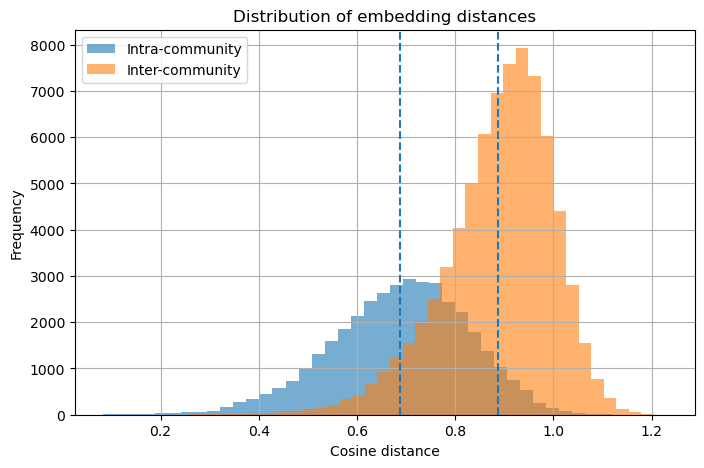

In [38]:
# distance distribution plot
plt.figure(figsize=(8,5))

plt.hist(intra, bins=40, alpha=0.6, label="Intra-community")
plt.hist(inter, bins=40, alpha=0.6, label="Inter-community")

plt.axvline(np.mean(intra), linestyle="--")
plt.axvline(np.mean(inter), linestyle="--")

plt.xlabel("Cosine distance")
plt.ylabel("Frequency")
plt.title("Distribution of embedding distances")
plt.legend()

plt.show()

To assess whether the node2vec embeddings capture the community structure of the network, we compare the cosine distances between node embeddings belonging to the same community and those belonging to different communities.
Using the best-performing configuration (𝑝=1,𝑞=4), the mean intra-community distance is 0.68, while the mean inter-community distance is 0.88, indicating that nodes within the same community tend to have substantially more similar embeddings than nodes from different communities.

The distribution of cosine distances further supports this result. Although some overlap between the two distributions is present, the inter-community distances are clearly shifted toward larger values, while intra-community distances are concentrated at lower values. This separation indicates that the learned embeddings effectively capture the underlying community organization of the network.

(475, 64) 475


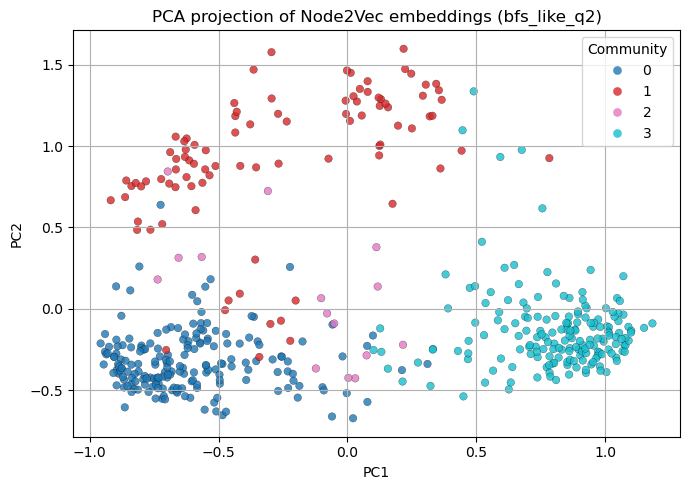

Explained variance ratio: [0.12144391 0.07401355]
Total explained variance: 0.19545746


In [ ]:
# PCA visualization
best_config = results_df.loc[0, "config"]

X_emb = embeddings_by_config[best_config]
nodes_emb = nodes_by_config[best_config]
y_emb = np.array([community_dict[node] for node in nodes_emb])

print(X_emb.shape, len(y_emb))  # devono coincidere

pca_emb = PCA(n_components=2)
X_emb_2d = pca_emb.fit_transform(X_emb)

plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_emb_2d[:, 0],
    X_emb_2d[:, 1],
    c=y_emb,
    cmap="tab10",
    alpha=0.8,
    s=30,
    edgecolors="k",
    linewidths=0.2
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of Node2Vec embeddings ({best_config})")
plt.legend(*scatter.legend_elements(), title="Community")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca_emb.explained_variance_ratio_)
print("Total explained variance:", pca_emb.explained_variance_ratio_.sum())

(475, 64) 475


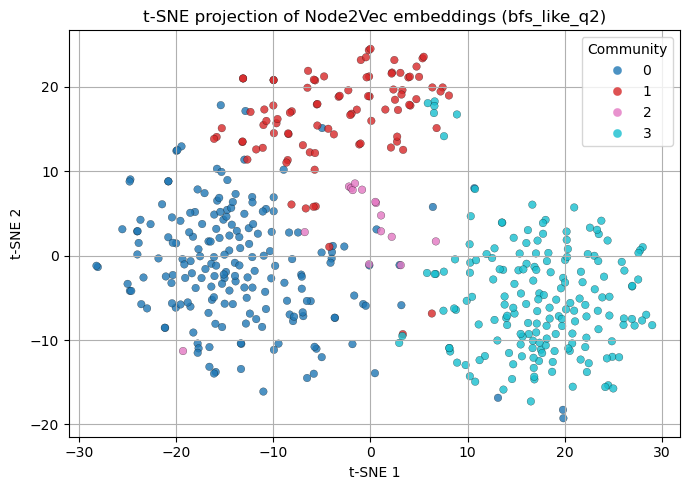

In [ ]:
# tsne visualization
best_config = results_df.loc[0, "config"]

X_emb = embeddings_by_config[best_config]
nodes_emb = nodes_by_config[best_config]
y_emb = np.array([community_dict[node] for node in nodes_emb])

print(X_emb.shape, len(y_emb))  # devono coincidere

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_emb)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_emb,
    cmap="tab10",
    alpha=0.8,
    s=30,
    edgecolors="k",
    linewidths=0.2
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"t-SNE projection of Node2Vec embeddings ({best_config})")
plt.legend(*scatter.legend_elements(), title="Community")
plt.tight_layout()
plt.show()

To better understand the structure captured by the Node2Vec embeddings, we projected the learned node representations into two dimensions using Principal Component Analysis. The resulting visualization reveals a clear clustering pattern aligned with the Louvain communities. Nodes belonging to the same community tend to occupy similar regions of the embedding space, indicating that the embeddings successfully capture the structural organization of the network.

This clear separation indicates that Node2Vec successfully captures the structural patterns associated with community membership. The embedding space therefore provides a highly informative representation of node positions in the network, which explains the strong performance of the classification model.

### GDV Feature Extraction
To compute Graphlet Degree Vectors (GDV), we used the orbit-count library, which efficiently calculates the number of times each node participates in different graphlet orbits. Graphlets are small induced subgraphs that capture local connectivity patterns around a node.

Since the orbit-count package does not currently provide precompiled wheels for Windows, the GDV features were computed in a Google Colab environment. The undirected version of the network (G_und) was exported as an edge list, loaded in Colab, and processed using the node_orbit_counts function.

The resulting matrix contains, for each node, the counts of its participation in different graphlet orbits. These features were then saved to a CSV file and imported into the main notebook, where they were used as input features for the node classification task.

In [ ]:
gdv_df = pd.read_csv("gdv_features.csv", index_col=0)
X_gdv = gdv_df.loc[nodes_ml].values

X_train_gdv = X_gdv[train_idx]
X_test_gdv = X_gdv[test_idx]

clf_gdv = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)

clf_gdv.fit(X_train_gdv, y_train)
y_pred_gdv = clf_gdv.predict(X_test_gdv)

acc_gdv = accuracy_score(y_test, y_pred_gdv)
f1_macro_gdv = f1_score(y_test, y_pred_gdv, average="macro")
f1_weighted_gdv = f1_score(y_test, y_pred_gdv, average="weighted")

print("\n=== GDV results ===")
print(f"Accuracy     : {acc_gdv:.4f}")
print(f"F1 macro     : {f1_macro_gdv:.4f}")
print(f"F1 weighted  : {f1_weighted_gdv:.4f}")

gdv_report = classification_report(y_test, y_pred_gdv)
print("\n=== Classification report: GDV ===")
print(gdv_report)


=== GDV results ===
Accuracy     : 0.7762
F1 macro     : 0.5823
F1 weighted  : 0.7686

=== Classification report: GDV ===
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        57
           1       0.63      0.79      0.70        28
           2       0.00      0.00      0.00         4
           3       0.90      0.83      0.87        54

    accuracy                           0.78       143
   macro avg       0.57      0.60      0.58       143
weighted avg       0.77      0.78      0.77       143



c:\Users\Leila\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Leila\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Leila\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# GDV + centrality features
eigenvector = nx.eigenvector_centrality(G_und, max_iter=1000)
katz = nx.katz_centrality(G_und, alpha=0.01, beta=1.0, max_iter=1000)
pagerank = nx.pagerank(G_und)

# centrality features
centrality_df = pd.DataFrame({
    "degree": [G_und.degree(n) for n in nodes_ml],
    "eig": [eigenvector[n] for n in nodes_ml],
    "katz": [katz[n] for n in nodes_ml],
    "pg": [pagerank[n] for n in nodes_ml],
}, index=nodes_ml)

# combine GDV + centrality
feature_df = pd.concat(
    [gdv_df.loc[nodes_ml], centrality_df],
    axis=1
)

X_gdv_plus = feature_df.values

X_train_gdv_plus = X_gdv_plus[train_idx]
X_test_gdv_plus = X_gdv_plus[test_idx]

clf_gdv_plus = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)

clf_gdv_plus.fit(X_train_gdv_plus, y_train)
y_pred_gdv_plus = clf_gdv_plus.predict(X_test_gdv_plus)

acc_gdv_plus = accuracy_score(y_test, y_pred_gdv_plus)
f1_macro_gdv_plus = f1_score(y_test, y_pred_gdv_plus, average="macro")
f1_weighted_gdv_plus = f1_score(y_test, y_pred_gdv_plus, average="weighted")

print("\n=== GDV + centrality results ===")
print(f"Accuracy     : {acc_gdv_plus:.4f}")
print(f"F1 macro     : {f1_macro_gdv_plus:.4f}")
print(f"F1 weighted  : {f1_weighted_gdv_plus:.4f}")


=== GDV + centrality results ===
Accuracy     : 0.8182
F1 macro     : 0.6162
F1 weighted  : 0.8085


## Final Comparison

In [61]:
extra_results = [
    {
        "config": "gdv_only",
        "p": np.nan,
        "q": np.nan,
        "accuracy": acc_gdv,
        "f1_macro": f1_macro_gdv,
        "f1_weighted": f1_weighted_gdv
    },
    {
        "config": "gdv_plus_centrality",
        "p": np.nan,
        "q": np.nan,
        "accuracy": acc_gdv_plus,
        "f1_macro": f1_macro_gdv_plus,
        "f1_weighted": f1_weighted_gdv_plus
    }
]

comparison_df = pd.concat(
    [results_df, pd.DataFrame(extra_results)],
    ignore_index=True
).sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n=== Final comparison ===")
print(comparison_df)


=== Final comparison ===
                config    p    q  accuracy  f1_macro  f1_weighted
0          bfs_like_q2  1.0  2.0  0.979021  0.948710     0.978609
1             baseline  1.0  1.0  0.965035  0.934576     0.964234
2          bfs_like_q4  1.0  4.0  0.951049  0.922732     0.951118
3  gdv_plus_centrality  NaN  NaN  0.818182  0.616210     0.808453
4             gdv_only  NaN  NaN  0.776224  0.582254     0.768557


## Interpretation of the Results

The results show that Node2Vec embeddings clearly outperform GDV-based representations in predicting node community membership. The best-performing configuration (𝑝=1, 𝑞=2) achieves a macro F1-score of approximately 0.95, indicating that the learned embeddings capture the community structure of the network very effectively.

This behavior is expected given the nature of the Node2Vec algorithm. By generating biased random walks and training a skip-gram model, Node2Vec learns node representations that reflect network proximity and neighborhood similarity, which are strongly related to community structure.

In contrast, the GDV representation performs substantially worse. Although GDV captures detailed information about the local structural roles of nodes, it does not directly encode the broader connectivity patterns that define communities. As a result, GDV features alone are less informative for this particular classification task.

Adding classical centrality measures to the GDV representation slightly improves performance, but the results remain significantly below those obtained with Node2Vec. This suggests that community membership in this network is better explained by embedding-based proximity than by local structural patterns alone.

Overall, these findings highlight the advantage of representation learning approaches such as Node2Vec when the goal is to capture mesoscopic structures like communities